In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving spotify dataset.csv to spotify dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("spotify dataset.csv")
df.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:

print(df.shape)
print(df.info())


print("Missing values:\n", df.isnull().sum())


df = df.dropna()


if 'playlist_genre' in df.columns:
    df['playlist_genre'] = df['playlist_genre'].astype('category').cat.codes

df.head()


NameError: name 'df' is not defined

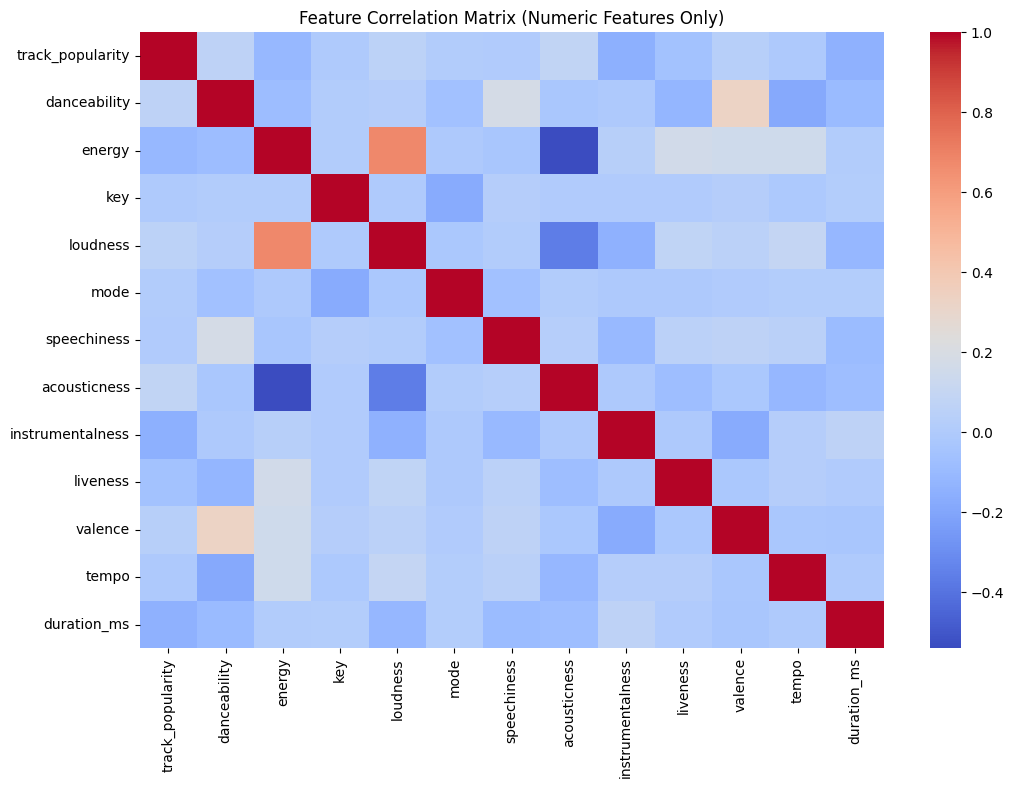

In [ ]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])  # select only numbers
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Matrix (Numeric Features Only)")
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler


features = df.select_dtypes(include=['int64','float64'])


scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaled feature shape:", scaled_features.shape)


Scaled feature shape: (32828, 13)


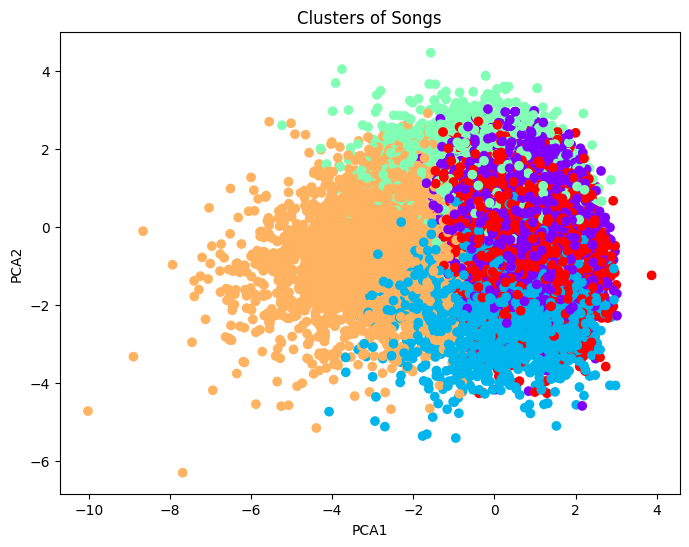

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)


pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_features)


plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df['Cluster'], cmap='rainbow')
plt.title("Clusters of Songs")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()


In [ ]:
print(df.columns)


Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'Cluster'],
      dtype='object')


In [ ]:
def recommend_song(song_name, df):
    if song_name not in df['track_name'].values:
        return "Song not found in dataset!"


    song_cluster = df[df['track_name'] == song_name]['Cluster'].values[0]


    similar_songs = df[df['Cluster'] == song_cluster].sample(5)


    return similar_songs[['track_name','artist_name','playlist_genre']]

In [ ]:
def recommend_song(song_name, df):
    if song_name not in df['track_name'].values:
        return "Song not found in dataset!"


    song_cluster = df[df['track_name'] == song_name]['Cluster'].values[0]

    similar_songs = df[df['Cluster'] == song_cluster].sample(5)

    cols_to_show = []
    for col in ['track_name', 'artists', 'artist_name', 'playlist_genre', 'playlist_name']:
        if col in df.columns:
            cols_to_show.append(col)

    return similar_songs[cols_to_show]

recommend_song("Shape of You", df)


,track_name,playlist_genre,playlist_name
13025,Black Dog - 1990 Remaster,5,Southern Rock/Classic Rock
29750,All Falls Down (feat. Juliander) - Mark Villa ...,0,Pop EDM Remixes
14648,Dirt in my Eyes,5,Modern Indie Rock // Alternative Rock / Garage...
3025,Viva La Vida,2,ELECTROPOP🐹
228,Heaven (feat. Veronica),2,Cardio


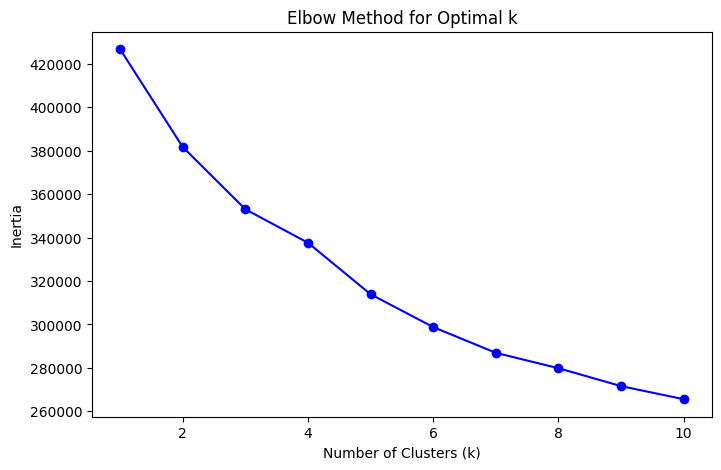

In [ ]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()
